<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>



# **Final Project: Boston Housing**


##### Estimated time needed: **60** minutes


#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [2]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

<ipython-input-2-b3fdaf15785b>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


#### Read the dataset in the csv file from the URL


In [3]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [4]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


## Task 1: Familiarize Yourself with the Dataset

In [7]:
#Display the first 5 rows of the dataset.
boston_df.head(5)

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [10]:
#Display the data types of each column.
boston_df.dtypes

Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS          float64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD           float64
TAX           float64
PTRATIO       float64
LSTAT         float64
MEDV          float64
dtype: object

In [17]:
#Check for missing values in each column.
boston_df.isnull().sum()

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

In [21]:
#Check for duplicate rows.
boston_df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
501    False
502    False
503    False
504    False
505    False
Length: 506, dtype: bool

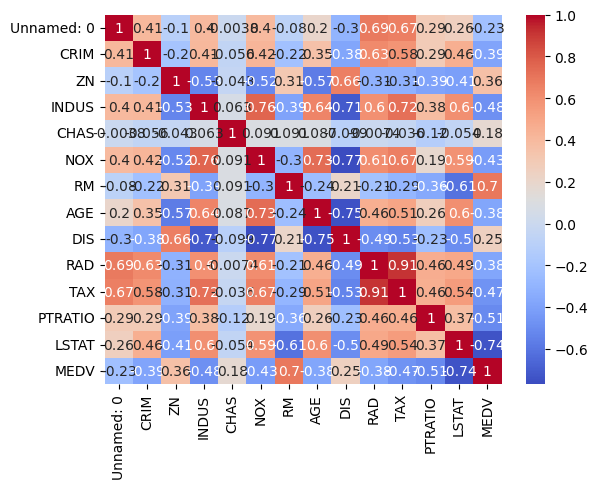

In [25]:
#Display the correlation matrix of the dataset.
import seaborn as sns
import matplotlib.pyplot as plt

# Tính toán tương quan
corr = boston_df.corr()

# Vẽ biểu đồ nhiệt (Heatmap)
sns.heatmap(corr, annot=True, cmap='coolwarm')

# Hiển thị biểu đồ
plt.show()

## Task 2: Generate Descriptive Statistics and Visualizations

In [27]:
#Display descriptive statistics of the dataset.
boston_df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


Outlier: 40
     Unnamed: 0      CRIM    ZN  INDUS  CHAS     NOX     RM    AGE     DIS  \
97           97   0.12083   0.0   2.89   0.0  0.4450  8.069   76.0  3.4952   
98           98   0.08187   0.0   2.89   0.0  0.4450  7.820   36.9  3.4952   
157         157   1.22358   0.0  19.58   0.0  0.6050  6.943   97.4  1.8773   
161         161   1.46336   0.0  19.58   0.0  0.6050  7.489   90.8  1.9709   
162         162   1.83377   0.0  19.58   1.0  0.6050  7.802   98.2  2.0407   
163         163   1.51902   0.0  19.58   1.0  0.6050  8.375   93.9  2.1620   
166         166   2.01019   0.0  19.58   0.0  0.6050  7.929   96.2  2.0459   
179         179   0.05780   0.0   2.46   0.0  0.4880  6.980   58.4  2.8290   
180         180   0.06588   0.0   2.46   0.0  0.4880  7.765   83.3  2.7410   
182         182   0.09103   0.0   2.46   0.0  0.4880  7.155   92.2  2.7006   
186         186   0.05602   0.0   2.46   0.0  0.4880  7.831   53.6  3.1992   
190         190   0.09068  45.0   3.44   0.0  0.4370

<AxesSubplot:>

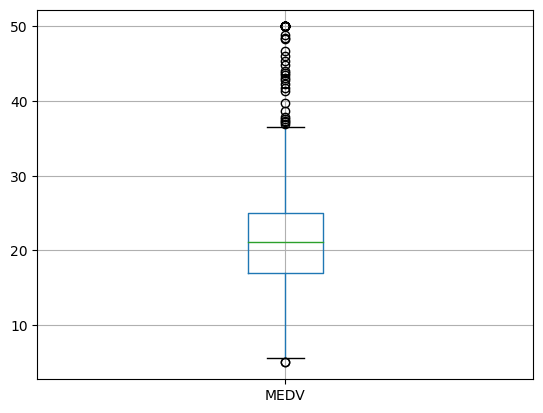

In [36]:
#Create a boxplot for MEDV (Median value of owner-occupied homes).
Q1_own = boston_df['MEDV'].quantile(0.25) 
Q3_own = boston_df['MEDV'].quantile(0.75)

IQR_own = Q3_own - Q1_own 

outliers = boston_df[ 
    (boston_df['MEDV'] < Q1_own - 1.5 * IQR_own) |
    (boston_df['MEDV'] > Q3_own + 1.5 * IQR_own) 
]

print(f'Outlier: {len(outliers)}')
print(outliers)

boston_df.boxplot(column = ['MEDV'])

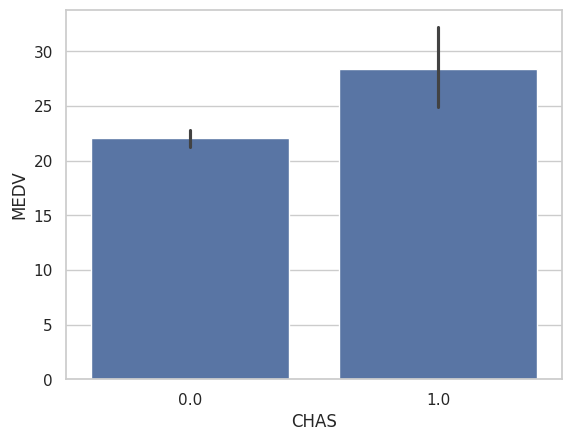

In [38]:
#Create a bar plot for CHAS (Charles River dummy variable).
sns.set(style="whitegrid")
ax = sns.barplot(x="CHAS", y="MEDV", data = boston_df)
plt.show()


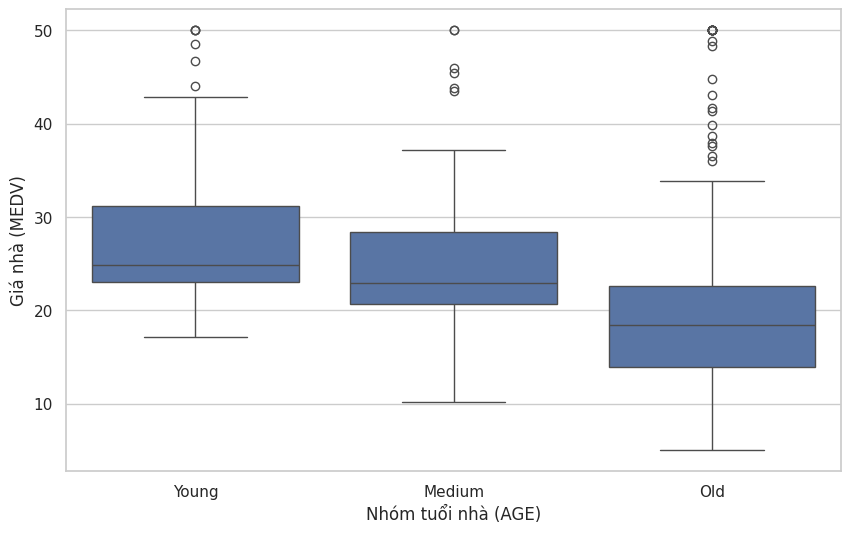

In [39]:
#Discretize AGE into three groups and create a boxplot of MEDV versus these groups
# --- BƯỚC 1: DISCRETIZE (Chia AGE thành 3 nhóm) ---
# Chúng ta dùng pd.cut để chia dữ liệu thành 3 khoảng (bins) bằng nhau
boston_df['AGE_div'] = pd.cut(boston_df['AGE'], bins=3, labels=['Young', 'Medium', 'Old'])

# --- BƯỚC 2: TẠO BOXPLOT ---
plt.figure(figsize=(10, 6))

# x là các nhóm AGE vừa tạo, y là giá nhà MEDV
sns.boxplot(x='AGE_div', y='MEDV', data=boston_df)

plt.xlabel('Nhóm tuổi nhà (AGE)')
plt.ylabel('Giá nhà (MEDV)')
plt.show()

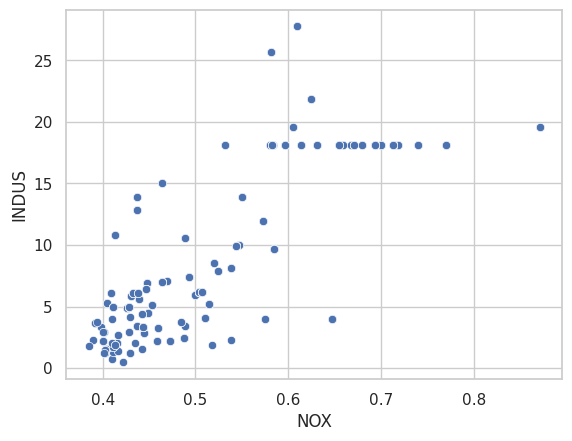

In [40]:
#Create a scatter plot showing the relationship between NOX (nitric oxide concentrations) and INDUS (non-retail business acres).
ax = sns.scatterplot(x = 'NOX', y = 'INDUS', data = boston_df)
plt.show()

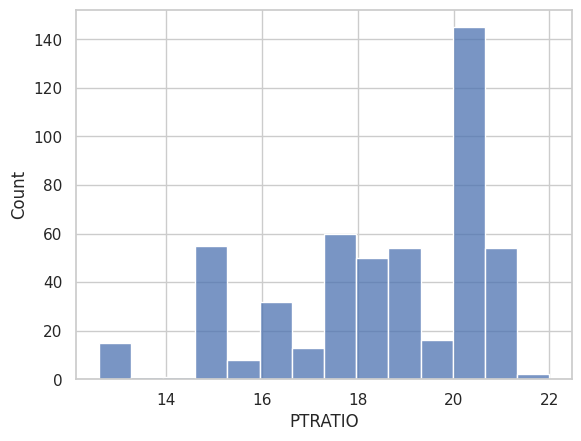

In [43]:
#Create a histogram for PTRATIO (pupil-teacher ratio).
ax = sns.histplot(x = 'PTRATIO', data = boston_df)
plt.show()

## Task 3: Apply Statistical Tests

In [44]:
#Use Levene’s test to check if the variances of MEDV for homes bounded by the Charles River (CHAS = 1) and those not bounded (CHAS = 0) are equal.
from scipy import stats

medv_chas_1 = boston_df[boston_df['CHAS'] == 1]['MEDV']

medv_chas_0 = boston_df[boston_df['CHAS'] == 0]['MEDV']

statistic, p_value = stats.levene(medv_chas_1, medv_chas_0)

print("Levene's Test Statistic:", statistic)
print("p-value:", p_value)

Levene's Test Statistic: 4.590342218715871
p-value: 0.03263097600633006


In [45]:
from scipy import stats

medv_chas_1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
medv_chas_0 = boston_df[boston_df['CHAS'] == 0]['MEDV']

t_stat, p_val = stats.ttest_ind(medv_chas_1, medv_chas_0)

print(f"T-test Statistic: {t_stat}, p-value: {p_val}")


T-test Statistic: 3.996437466090509, p-value: 7.390623170519905e-05


In [46]:
boston_df['AGE_Group'] = pd.cut(boston_df['AGE'], bins=3, labels=['Group 1', 'Group 2', 'Group 3'])


group1 = boston_df[boston_df['AGE_Group'] == 'Group 1']['MEDV']
group2 = boston_df[boston_df['AGE_Group'] == 'Group 2']['MEDV']
group3 = boston_df[boston_df['AGE_Group'] == 'Group 3']['MEDV']


f_stat, p_val = stats.f_oneway(group1, group2, group3)

print(f"ANOVA F-statistic: {f_stat}, p-value: {p_val}")


ANOVA F-statistic: 36.434981466845564, p-value: 1.6701480198809046e-15


In [47]:
corr_coef, p_val = stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])
print(f" (r): {corr_coef}, p-value: {p_val}")

 (r): 0.7636514469209192, p-value: 7.913361061210442e-98


In [50]:
import statsmodels.api as sm

X = boston_df['DIS']
y = boston_df['MEDV'] 

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           1.21e-08
Time:                        20:46:32   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0